This notebook for Stardist applicationis adoptted from https://github.com/stardist/stardist/blob/main/examples/2D/3_prediction.ipynb

Students can use this as an initial notebook for more images with specific models and parameters.

Liya Ding 2024.10.01

In [216]:
import sys
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread, imwrite
from csbdeep.utils import normalize
from csbdeep.utils import download_and_extract_zip_file
import tifffile
from skimage.transform import resize

from cellpose import models, io


import pandas as pd
np.random.seed(6)


In [217]:
import os

In [218]:
image_folder = '/mnt/d/lding/CLS/mousumiLiuDinner/revision_data_raw/MT encapsulated GUV wo Tau/MT encapsulated GUV wo Tau 469_469'

output_folder = '/mnt/d/lding/CLS/mousumiLiuDinner/revision_data_output/MT encapsulated GUV wo Tau 469_469'
processed_folder = output_folder+'/processed_MT/'

if not os.path.isdir(output_folder):   os.makedirs(output_folder)
if not os.path.isdir(processed_folder):   os.makedirs(processed_folder)

In [219]:
im_width = 469

In [220]:
df = pd.DataFrame(columns=['GUV_folder_path','GUV_file_name','MT_folder_path','MT_file_name','condition','date', 'tau','facin','a_actinin'])

# print(sub_folder)
filename_list = [x for x in os.listdir(image_folder)  if os.path.isfile(os.path.join(image_folder, x)) and ('561.TIF' in x) ]
for  filename_ID in range(len(filename_list)):
    GUV_filename =  filename_list[filename_ID]

    MT_filename = GUV_filename.replace("w2561.TIF","MTs.TIF")

    GUV_file_path = os.path.join(image_folder, GUV_filename)
    MT_file_path = os.path.join(image_folder, MT_filename)

    if(os.path.isfile(GUV_file_path) and os.path.isfile(MT_file_path)):
    ##########################
    # Liya check if both path exists                
        # print(file_path)                    
        s = pd.DataFrame([[image_folder, GUV_filename,image_folder, MT_filename, 'no_tau','0']],
                        columns=['GUV_folder_path','GUV_file_name','MT_folder_path','MT_file_name','condition','date'])
        df = pd.concat([df, s], ignore_index=True)
        print(GUV_filename +' and '+ MT_filename)
        


01_w2561.TIF and 01_MTs.TIF
0_w2561.TIF and 0_MTs.TIF
10_w2561.TIF and 10_MTs.TIF
11_w2561.TIF and 11_MTs.TIF
12_w2561.TIF and 12_MTs.TIF
13_w2561.TIF and 13_MTs.TIF
14_w2561.TIF and 14_MTs.TIF
15_w2561.TIF and 15_MTs.TIF
16_w2561.TIF and 16_MTs.TIF
17_w2561.TIF and 17_MTs.TIF
18_w2561.TIF and 18_MTs.TIF
20_w2561.TIF and 20_MTs.TIF
21_w2561.TIF and 21_MTs.TIF
22_w2561.TIF and 22_MTs.TIF
23_w2561.TIF and 23_MTs.TIF
24_w2561.TIF and 24_MTs.TIF
25_w2561.TIF and 25_MTs.TIF
26_w2561.TIF and 26_MTs.TIF
27_w2561.TIF and 27_MTs.TIF
29_w2561.TIF and 29_MTs.TIF
2_w2561.TIF and 2_MTs.TIF
3_w2561.TIF and 3_MTs.TIF
4_w2561.TIF and 4_MTs.TIF
5_w2561.TIF and 5_MTs.TIF
6_w2561.TIF and 6_MTs.TIF
7_w2561.TIF and 7_MTs.TIF
8_w2561.TIF and 8_MTs.TIF
9_w2561.TIF and 9_MTs.TIF


### Segmentation with cellpose pretrained models


In [221]:
# DEFINE CELLPOSE MODEL
# model_type='cyto3' or model_type='nuclei'
model = models.Cellpose(gpu=False, model_type='cyto3')



/home/ldin/anaconda3/envs/tf-gpu/lib/python3.9/site-packages/cellpose/resnet_torch.py:280: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(filename, ma

In [222]:
from skimage.measure import label, regionprops, regionprops_table
from matplotlib import cm
from skimage import filters

In [223]:
from matplotlib import cm
# build the colormap with iterative tab10
tab10 = cm.get_cmap('tab10', 10)
for i in range(10):
    tab10.colors = np.concatenate([tab10.colors,tab10.colors],axis=0)    
tab10.colors = np.concatenate([np.zeros([1,4]),tab10.colors],axis=0)

newmap = cm.get_cmap('tab10', 200+1)
newmap.colors = tab10.colors[0:200+1,:]
newmap.colors[0,:]  = np.zeros([1,4])
newmap.colors[0,3] = 1

/tmp/ipykernel_1207746/1700555406.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  tab10 = cm.get_cmap('tab10', 10)
/tmp/ipykernel_1207746/1700555406.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  newmap = cm.get_cmap('tab10', 200+1)


In [224]:
number_img = len(df)
guv_img_all = np.zeros([number_img,im_width,im_width])
mt_img_all = np.zeros([number_img,im_width,im_width])

for row_ID in range(number_img): 
    GUV_file_path = os.path.join(df.iloc[row_ID]['GUV_folder_path'],df.iloc[row_ID]['GUV_file_name'])
    MT_file_path = os.path.join(df.iloc[row_ID]['MT_folder_path'],df.iloc[row_ID]['MT_file_name'])
           
    # print(file_path)
    guv_img = imread(GUV_file_path)/(1.0)
    mt_img = imread(MT_file_path)/(1.0)
    if guv_img.ndim ==3:
        guv_img = guv_img.max(axis=0).squeeze()
    if mt_img.ndim ==3:
        mt_img = mt_img.max(axis=0).squeeze()

    guv_img_all[row_ID,0:guv_img.shape[0],0:guv_img.shape[1]] = guv_img
    mt_img_all[row_ID,0:mt_img.shape[0],0:mt_img.shape[1]] = mt_img
    

In [225]:
guv_img_all[guv_img_all==0] = np.nan
mt_img_all[mt_img_all==0] = np.nan

In [226]:
guv_bg_img = np.nanmedian(guv_img_all, axis=0)
mt_bg_img = np.nanmedian(mt_img_all, axis=0)


from skimage.filters import median, gaussian
from skimage.morphology import disk

guv_bg_img_filtered = median(guv_bg_img, disk(5))
mt_bg_img_filtered  = median(mt_bg_img, disk(5))

# guv_bg_img_filtered_smooth = gaussian(guv_bg_img_filtered, 5)
# mt_bg_img_filtered_smooth = gaussian(mt_bg_img_filtered, 5)


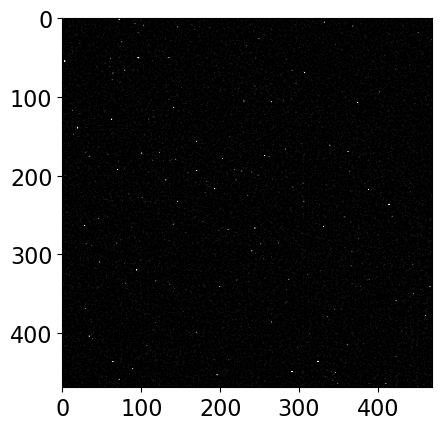

In [227]:
plt.imshow(guv_bg_img - guv_bg_img_filtered, clim=(0,70), cmap='gray')

In [228]:
guv_bg_int = np.nanmedian(guv_bg_img.ravel()) 
mt_bg_int = np.nanmedian(mt_bg_img.ravel()) 

In [229]:
mt_bg_int

305.0

In [230]:
guv_bg_int

119.0

In [231]:
mt_bg_int = 122

In [232]:
guv_bg_int = 110

In [233]:
guv_img_all = np.nan_to_num(guv_img_all, nan=guv_bg_int)
mt_img_all = np.nan_to_num(mt_img_all, nan=mt_bg_int)

In [234]:
pad_guv_img_all = np.zeros([number_img,im_width+128,im_width+128]) + guv_bg_int
guv_img_no_bg = np.zeros([number_img,im_width,im_width])

pad_mt_img_all = np.zeros([number_img,im_width+128,im_width+128]) + mt_bg_int
mt_img_no_bg = np.zeros([number_img,im_width,im_width])

for i in range(number_img):

    GUV_file_name = df.iloc[i]['GUV_file_name']
    condition = df.iloc[i]['condition']
    date = df.iloc[i]['date']

    fig1, ax1 = plt.subplots(2, 4, figsize=(16, 8))
    fig1.suptitle(condition+', '+date+', '+GUV_file_name)
    ax1[0,0].imshow(guv_bg_img,cmap='gray',vmin=80,vmax=500)
    ax1[0,0].axis('off')
    ax1[0,0].set_title('bg')
    ax1[0,1].imshow(guv_img_all[i,:,:],cmap='gray',vmin=80,vmax=500)
    ax1[0,1].axis('off')
    ax1[0,1].set_title('org')
    # guv_img_no_bg[i,:,:]  = guv_img_all[i,:,:] 
    guv_img_no_bg[i,:,:]  = guv_img_all[i,:,:] - guv_bg_img_filtered + guv_bg_int + 20
    
    ax1[0,2].imshow(guv_img_no_bg[i,:,:],cmap='gray',vmin=80,vmax=500)
    ax1[0,2].axis('off')
    ax1[0,2].set_title('bg rm')
    pad_guv_img_all[i,64:64+im_width,64:64+im_width] = guv_img_no_bg[i,:,:]
    pad_guv_img_all[i,:] = pad_guv_img_all[i,:] + 10
    ax1[0,3].imshow(pad_guv_img_all[i,:,:],cmap='gray',vmin=80,vmax=500)
    ax1[0,3].axis('off')
    ax1[0,3].set_title('pd')

    ax1[1,0].imshow(mt_bg_img,cmap='gray',vmin=80,vmax=500)
    ax1[1,0].axis('off')
    ax1[1,0].set_title('bg')
    ax1[1,1].imshow(mt_img_all[i,:,:],cmap='gray',vmin=80,vmax=500)
    ax1[1,1].axis('off')
    ax1[1,1].set_title('org')
    mt_img_no_bg[i,:,:]  = mt_img_all[i,:,:] - mt_bg_img_filtered + mt_bg_int + 20
    # mt_img_no_bg[i,:,:]  = mt_img_all[i,:,:] 
    ax1[1,2].imshow(mt_img_no_bg[i,:,:],cmap='gray',vmin=80,vmax=500)
    ax1[1,2].axis('off')
    ax1[1,2].set_title('bg rm')
    pad_mt_img_all[i,64:64+im_width,64:64+im_width] = mt_img_no_bg[i,:,:]
    pad_mt_img_all[i,:] = pad_mt_img_all[i,:] + 10
    ax1[1,3].imshow(pad_mt_img_all[i,:,:],cmap='gray',vmin=80,vmax=500)
    ax1[1,3].axis('off')
    ax1[1,3].set_title('pd')

    fig1.savefig(processed_folder+'pre-processed-guv-mt-'+ str(i).zfill(2) +'.jpg')
    plt.close(fig1)


In [235]:
stardist_display_folder =  processed_folder + 'GUV-MT_obj_detect_filter_selected_std15'
obj_crop_panel_folder = processed_folder + 'GUV-MT_obj_panel_selected_std15'
tiff_folder= processed_folder + 'GUV-MT_obj_tiff_selected_std15'
png_folder= processed_folder + 'GUV-MT_obj_png_selected_std15'  
singlecell_annotation_folder = processed_folder + 'singlecell_annotation_selected_std15' 

if not os.path.isdir(stardist_display_folder):   os.makedirs(stardist_display_folder)
if not os.path.isdir(obj_crop_panel_folder):   os.makedirs(obj_crop_panel_folder)
if not os.path.isdir(tiff_folder):   os.makedirs(tiff_folder)
if not os.path.isdir(png_folder):   os.makedirs(png_folder)
os.makedirs(singlecell_annotation_folder, exist_ok=True)

In [236]:
mt_img_medianfiltered = median(mt_img, disk(3))

In [237]:
sigma=1

In [238]:
guv_img_all_smooth = guv_img_all.copy()
mt_img_all_smooth = mt_img_all.copy()
for row_ID in range(df.shape[0]): 
    guv_img_all_smooth = filters.gaussian(guv_img_all[row_ID], sigma)
    mt_img_all_smooth = filters.gaussian(mt_img_all[row_ID], sigma)    

guv_1p = np.percentile(guv_img_all_smooth[guv_img_all_smooth>0],0.001)
guv_99p = np.percentile(guv_img_all_smooth[guv_img_all_smooth>0],99.999)
mt_1p = np.percentile(mt_img_all_smooth[mt_img_all_smooth>0],0.001)
mt_99p = np.percentile(mt_img_all_smooth[mt_img_all_smooth>0],99.999)



In [239]:
mt_1p=50

In [240]:
mt_99p=1000

In [241]:
(mt_bg_int-mt_1p)/(mt_99p-mt_1p)

0.07578947368421053

In [242]:
cell_cropped_array =np.zeros([2000,96,96])
cell_cropped_cellalone_array =np.zeros([2000,96,96])
cell_ind=0
plt.rcParams.update({'font.size': 16})
sigma = 1



cell_index = 0
    
cell_df = pd.DataFrame(columns=['GUV_folder_path','GUV_file_name','MT_folder_path','MT_file_name','condition','date','cell_ID','cell_index','cx','cy','diameter','bbox_1','bbox_2','bbox_3','bbox_4','obj_folder','obj_filename'])

for row_ID in range(df.shape[0]): 
# for row_ID in range(20): 
    GUV_file_path = os.path.join(df.iloc[row_ID]['GUV_folder_path'],df.iloc[row_ID]['GUV_file_name'])
    MT_file_path = os.path.join(df.iloc[row_ID]['MT_folder_path'],df.iloc[row_ID]['MT_file_name'])
    
    GUV_folder_path = df.iloc[row_ID]['GUV_folder_path']
    MT_folder_path = df.iloc[row_ID]['MT_folder_path']
    GUV_file_name = df.iloc[row_ID]['GUV_file_name']
    MT_file_name = df.iloc[row_ID]['MT_file_name']
    condition = df.iloc[row_ID]['condition']
    date = df.iloc[row_ID]['date']
    
    guv_img = guv_img_all[row_ID,:,:]
    mt_img = mt_img_all[row_ID,:,:]
    mt_img_medianfiltered = median(mt_img, disk(3))
    # img = imread(file_path)
    # img = np.sqrt(img)
    guv_smooth = filters.gaussian(guv_img, sigma)
    guv_img_normed = normalize(guv_smooth,1,99)
    mt_smooth = filters.gaussian(mt_img_medianfiltered, sigma)
    guv_img_normed = (guv_smooth-guv_1p)/(guv_99p-guv_1p)
    guv_img_normed[guv_img_normed<0] = 0
    guv_img_normed[guv_img_normed>1] = 1
    mt_img_normed = (mt_smooth-mt_1p)/(mt_99p-mt_1p)
    mt_img_normed[mt_img_normed<0] = 0
    mt_img_normed[mt_img_normed>1] = 1
    
    guv_mt_img = np.zeros([2,im_width,im_width])
    guv_mt_img[0,:] = guv_img_normed
    guv_mt_img[1,:] = mt_img_normed
    
    guv_img_pad = pad_guv_img_all[row_ID,:,:]
    mt_img_pad = pad_mt_img_all[row_ID,:,:]
    mt_img_pad = median(mt_img_pad, disk(3))
    
       # cellpose
    labels, flows, styles, diams = model.eval(guv_mt_img[:,::2,::2],channels=[1,2])
    us_manual = np.zeros([im_width,im_width])
    us_manual[::2,::2]=labels
    us_manual[1::2,::2]=labels[:-1,:]
    us_manual[::2,1::2]=labels[:,:-1]
    us_manual[1::2,1::2]=labels[:us_manual[1::2,1::2].shape[0],:us_manual[1::2,1::2].shape[1]]
    
    labels = us_manual.astype(int)
    
    fig2, ax2 = plt.subplots(2, 3, figsize=(16, 8))
    fig2.suptitle(condition+', '+date+', '+GUV_file_name)
    ax2[0,0].imshow(guv_img_normed, clim=(0,1), cmap='gray')    
    ax2[0,0].axis('off')
    ax2[0,0].set_title('GUV')
    ax2[0,1].imshow(guv_img_normed, clim=(0,1), cmap='gray')
    ax2[0,1].imshow(labels, cmap=newmap, alpha=0.7,interpolation='None',vmax = 201,vmin = 0)
    ax2[0,1].axis('off')
    ax2[0,1].set_title('Segmentation')
    
    ax2[1,0].imshow(mt_img_normed, clim=(0,1), cmap='gray')    
    ax2[1,0].axis('off')
    ax2[1,0].set_title('MT')
    
    ax2[1,1].imshow(mt_img_normed, clim=(0,1), cmap='gray')
    ax2[1,1].imshow(labels, cmap=newmap, alpha=0.7,interpolation='None',vmax = 201,vmin = 0)
    ax2[1,1].axis('off')
    ax2[1,1].set_title('Segmentation')

    regionprops_pax = regionprops(labels,intensity_image=mt_img)

    bad_region_flag = np.zeros(labels.max())

    for region_i in range(0,labels.max()):
        # print([regionprops_pax[region_i]['Area'],regionprops_pax[region_i]['Eccentricity']])
        if(regionprops_pax[region_i]['Eccentricity']>0.5 or regionprops_pax[region_i]['Area']<1000 or regionprops_pax[region_i]['Area']>40000):
            bad_region_flag[region_i]=1
            labels[labels==region_i+1] =0
            continue
        else:
            img_content = mt_img_medianfiltered[labels==region_i+1]
            img_content = img_content[img_content>mt_bg_int]
            if(img_content.shape[0] == 0):
                bad_region_flag[region_i] = 1
                labels[labels==region_i+1] = 0       
                continue
            else:
                # print(img_content.std())
                if(img_content.std()<15):
                    bad_region_flag[region_i] = 1
                    labels[labels==region_i+1] = 0       
                    continue

    
    ax2[0,2].imshow(guv_img_normed, clim=(0,1), cmap='gray')
    ax2[0,2].imshow(labels, cmap=newmap, alpha=0.7,interpolation='None',vmax = 201,vmin = 0)
    ax2[0,2].axis('off')
    ax2[0,2].set_title('filtered')


    ax2[1,2].imshow(mt_img_normed, clim=(0,1), cmap='gray')
    # ax2[1,2].imshow(labels, cmap=newmap, alpha=0.7,interpolation='None',vmax = 201,vmin = 0)
    ax2[1,2].axis('off')
    ax2[1,2].set_title('filtered')

   
    if labels.max() == 0:   
        fig2.savefig(os.path.join(stardist_display_folder, condition+'-'+date+'-'+GUV_file_name+'_cellpose_filter.png'))
        plt.close(fig2)     
        continue
    
    labels_pad = np.zeros_like(guv_img_pad)
    labels_pad[64:64+im_width,64:64+im_width] = labels
    

    fig3, ax3 = plt.subplots(1, int(len(regionprops_pax) -bad_region_flag.sum()), figsize=(12, 6))

    fig3.suptitle(condition+', '+date+', ' + GUV_file_name)
    good_ind = 0
    for obj_i in range(len(regionprops_pax)):
        if(bad_region_flag[obj_i]>0):
            continue
        good_ind = good_ind + 1
        Centroid = regionprops_pax[obj_i]['Centroid']
        BBox = regionprops_pax[obj_i]['bbox']
        Area = regionprops_pax[obj_i]['area']
        Diameter = regionprops_pax[obj_i]['equivalent_diameter_area']
        cell_ID = regionprops_pax[obj_i]['label']
        
        cx = round(Centroid[0]) + 64
        cy = round(Centroid[1]) + 64


        mt_img_pad = np.zeros([im_width+128,im_width+128]) + (mt_bg_int-mt_1p)/(mt_99p-mt_1p)
        mt_img_pad[64:-64,64:-64] = mt_img_normed/(1.4)

        crop_img = mt_img_pad[cx-48:cx+48,cy-48:cy+48]
        crop_label = (labels_pad[cx-48:cx+48,cy-48:cy+48]).copy().astype(float)


        radius_estimated = Diameter/2
        circle = plt.Circle((cy-64+1, cx-64+1), radius_estimated, color=newmap.colors[obj_i+1,:], fill=False, linewidth=3)
        ax2[1,2].add_patch(circle)

        
        crop_img_cellalone = np.zeros_like(crop_img) + (mt_bg_int-mt_1p)/(mt_99p-mt_1p)

        mask = crop_label==cell_ID
        mask_smooth = filters.gaussian(mask.astype(float), sigma)
        mask_smooth_bw = mask_smooth>0.1

        crop_img_cellalone[mask_smooth_bw>0] = crop_img[mask_smooth_bw>0]
        crop_img_cellalone[crop_img_cellalone<(mt_bg_int-mt_1p)/(mt_99p-mt_1p)]=(mt_bg_int-mt_1p)/(mt_99p-mt_1p)
        # crop_img_cellalone = crop_img_cellalone - 0.
        cell_cropped_array[cell_ind,:,:] = crop_img
        cell_cropped_cellalone_array[cell_ind,:,:]=crop_img_cellalone
        cell_ind = cell_ind+1

        if len(regionprops_pax) -bad_region_flag.sum() == 1:
            ax3.imshow(crop_img_cellalone,cmap='gray',vmin=20,vmax=400)
            ax3.axis('off')
            ax3.set_title('obj '+str(good_ind).zfill(2))
        else:
            ax3[good_ind-1].imshow(crop_img_cellalone,cmap='gray',vmin=20,vmax=400)
            ax3[good_ind-1].axis('off')
            ax3[good_ind-1].set_title('obj '+str(good_ind).zfill(2))

        cell_index = cell_index + 1       
        

        fig4, ax4 = plt.subplots(2, 3, figsize=(12, 8))
        fig4.suptitle(condition+', '+date+', '+GUV_file_name)
        ax4[0,0].imshow(guv_img_normed, clim=(0,1), cmap='gray')    
        ax4[0,0].axis('off')
        ax4[0,0].set_title('img')    
        ax4[0,0].set_title('GUV')
    
        ax4[0,1].imshow(guv_img_normed, clim=(0,1), cmap='gray')
        ax4[0,1].imshow(labels, cmap=newmap, alpha=0.7,interpolation='None',vmax = 201,vmin = 0)
        ax4[0,1].axis('off')
        ax4[0,1].set_title('filtered')

        ax4[1,0].imshow(mt_img_normed, clim=(0,1), cmap='gray')    
        ax4[1,0].axis('off')
        ax4[1,0].set_title('MT')

        ax4[1,1].imshow(mt_img_normed, clim=(0,1), cmap='gray')
        ax4[1,1].axis('off')       
        circle4 = plt.Circle((cy-64+1, cx-64+1), radius_estimated, color=newmap.colors[obj_i+1,:], fill=False, linewidth=3)         
        ax4[1,1].add_patch(circle4)
        ax4[1,1].set_title('In this image: Cell ' + str(cell_ID).zfill(2)  )
        
        ax4[0,2].axis('off') 
        ax4[0,2].set_title('All cell index='+str(cell_index).zfill(4))
        
        display_image = crop_img_cellalone 
        # display_image = display_image/(3)
        # display_image[display_image<0]=0
        # display_image[display_image>255]=255
        
        ax4[1,2].imshow(display_image, clim=(0,1), cmap='gray')
        ax4[1,2].set_title('Cropped object')
        ax4[1,2].axis('off') 
        
        

        fig4.savefig(os.path.join(singlecell_annotation_folder, condition+'-'+date+'-'+GUV_file_name+'_cell'+str(cell_ID).zfill(2)+'_cellindex='+str(cell_index).zfill(4)+'.png'))
        plt.close(fig4)



        # obj_filename = condition+'-'+date+'-'+ GUV_file_name + '_cell'+str(cell_ID).zfill(2)+'_cellindex='+str(cell_index).zfill(4)+'.png'
        # tifffile.imsave(os.path.join(png_folder, obj_filename),crop_img.astype(np.float16))  
        
        # obj_filename = condition+'-'+date+'-'+ GUV_file_name + '_cell'+str(cell_ID).zfill(2)+'_cellindex='+str(cell_index).zfill(4)+'.tif'
        # tifffile.imwrite(os.path.join(tiff_folder, obj_filename),crop_img.astype(np.float16))  


        display_image = display_image*255
        display_image[display_image>=255]=254

        obj_filename = condition+'-'+date+'-'+ GUV_file_name + '_cell'+str(cell_ID).zfill(2)+'_cellindex'+str(cell_index).zfill(4)+'.png'
        tifffile.imwrite(os.path.join(png_folder, obj_filename),np.clip(display_image, 0, 255).astype(np.uint8))  
        

        obj_filename = condition+'-'+date+'-'+ GUV_file_name + '_cell'+str(cell_ID).zfill(2)+'_cellindex'+str(cell_index).zfill(4)+'.tif'
        
        tifffile.imwrite(
            os.path.join(tiff_folder, obj_filename),
            crop_img_cellalone.astype(np.float32),
            imagej=True,             
            metadata={'axes': 'YX'}  
        )  

        
        s = pd.DataFrame([[GUV_folder_path, GUV_file_name, MT_folder_path, MT_file_name, condition,date,cell_ID, cell_index,Centroid[0],Centroid[1],Diameter,BBox[0],BBox[1],BBox[2],BBox[3],tiff_folder,obj_filename]],
                         columns=['GUV_folder_path','GUV_file_name','MT_folder_path','MT_file_name','condition','date','cell_ID','cell_index','cx','cy','diameter','bbox_1','bbox_2','bbox_3','bbox_4','obj_folder','obj_filename'])
        
        cell_df = pd.concat([cell_df, s], ignore_index=True)

    fig2.savefig(os.path.join(stardist_display_folder, condition+'-'+date+'-'+GUV_file_name+'_cellpose_filter.png'))
    plt.close(fig2)    

    fig3.savefig(os.path.join(obj_crop_panel_folder, condition+'-'+date+'-'+GUV_file_name+'_guv_mt_obj_crop_panel.png'))    
    plt.close(fig3)

# tifffile.imwrite(os.path.join(processed_folder, 'mt_all_cell_cropped_array.tiff'),cell_cropped_array.astype(np.float16))  
# tifffile.imwrite(os.path.join(processed_folder, 'mt_all_cellalone_cropped_array.tiff'),cell_cropped_cellalone_array.astype(np.float16))  


/tmp/ipykernel_1207746/3815797981.py:246: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cell_df = pd.concat([cell_df, s], ignore_index=True)


In [243]:
(mt_bg_int-mt_1p)/(mt_99p-mt_1p)*255

19.326315789473686

In [244]:
us_manual[1::2,::2].shape

(234, 235)

In [245]:
labels.shape

(469, 469)

In [246]:
cell_df.to_csv(os.path.join(processed_folder, 'guv_mt_cell_df_circle_selected_std15.csv'))

In [247]:
tifffile.imwrite(os.path.join(processed_folder, 'mt_all_cellalone_cropped_array_selected_std15.tiff'),cell_cropped_cellalone_array.astype(np.float16))  

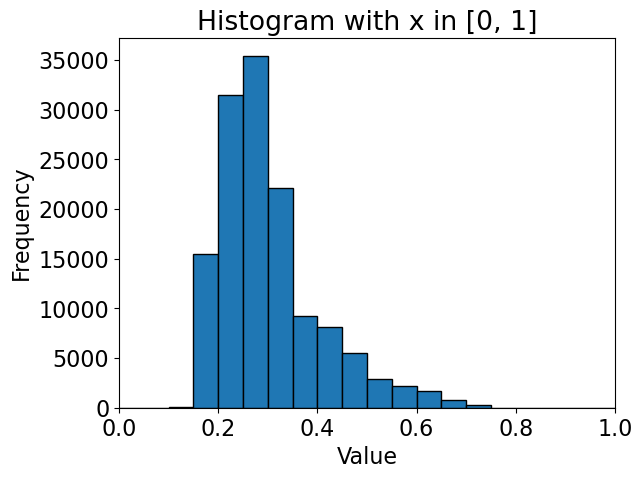

In [248]:
bins = np.linspace(0, 1, 21)  # 20 bins between 0 and 1

plt.hist(cell_cropped_cellalone_array[cell_cropped_cellalone_array>20/255], bins=bins, edgecolor='black')
plt.xlim(0, 1)  # Set x-axis to [0, 1]
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram with x in [0, 1]")
plt.show()